# Unit 1 — Time Domain Analysis of Race Entropy Signal

**Syllabus coverage:** Unit 1 — Introduction to Signals and Time Domain Operations

**Experiments covered:** #1 (Signal Visualisation), #2 (Autocorrelation), #3 (Convolution)

This notebook treats each race's Shannon entropy as a discrete-time signal and applies
fundamental time-domain operations: visualisation, autocorrelation, and convolution-based smoothing.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal as sp_signal
from scipy import stats
from statsmodels.tsa.stattools import pacf

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

REPO_ROOT = Path('.').resolve().parent
DATA_DIR = REPO_ROOT / 'data' / 'processed'
FIG_DIR = REPO_ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SAVEKW = dict(dpi=150, bbox_inches='tight')

## Section 1 — Signal Visualisation (Experiment #1)

We load the chronological entropy signal and visualise it as a discrete-time signal.

In [6]:
# Load entropy signal
df = pd.read_csv(DATA_DIR / 'entropy_signal.csv', parse_dates=['meet_date'])
print(f'Loaded {len(df):,} races spanning {df["meet_date"].min().date()} to {df["meet_date"].max().date()}')
df.head()

Loaded 6,759 races spanning 2010-07-15 to 2026-03-08


,race_seq_id,meet_date,venue,race_no,field_size,entropy_H,entropy_H_norm,entropy_bin,overround,winner_prob,winner_was_favourite,season,weather,track_condition,track_condition_category,venue_code
0,1,2010-07-15,Mumbai,1,8,2.832120,0.944040,high,0.046978,0.254701,True,NaN,Cloudy,Unknown,Unknown,0
1,2,2010-07-15,Mumbai,2,7,2.665033,0.949304,high,0.011880,0.123532,False,NaN,Cloudy,Unknown,Unknown,0
2,3,2010-07-15,Mumbai,3,9,2.475153,0.780824,low,0.163233,0.477596,True,NaN,Cloudy,Unknown,Unknown,0
3,4,2010-07-15,Mumbai,4,10,3.014458,0.907442,high,0.135607,0.167731,False,NaN,Cloudy,Unknown,Unknown,0
4,5,2010-07-15,Mumbai,5,9,2.482634,0.783184,low,0.214078,0.253437,False,NaN,Cloudy,Unknown,Unknown,0


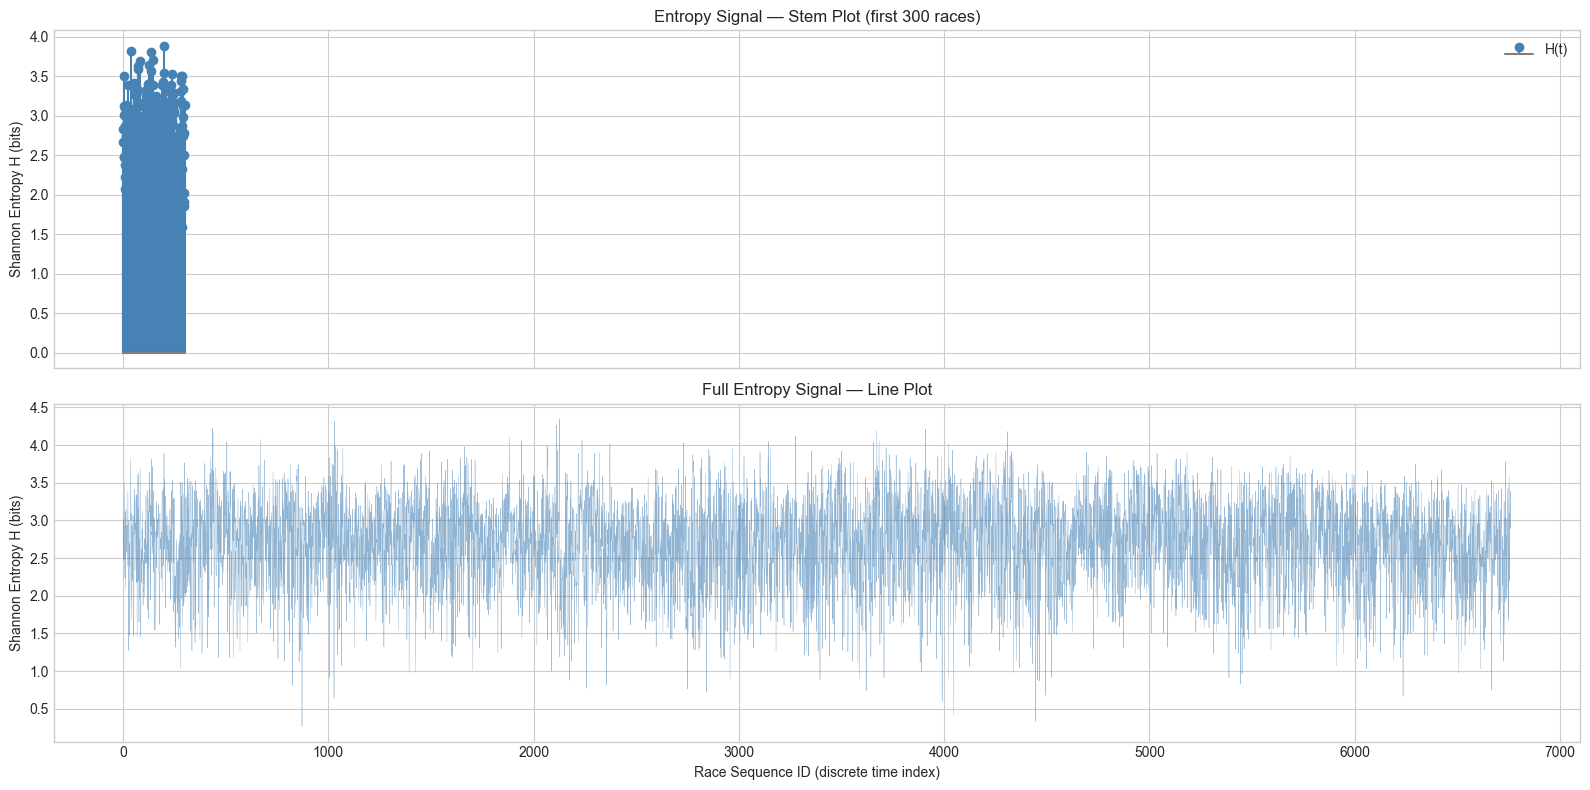

In [7]:
# Stem plot and line plot of entropy_H
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Show first 300 races for readability
subset = df.head(300)
axes[0].stem(subset['race_seq_id'], subset['entropy_H'],
             linefmt='steelblue', markerfmt='o', basefmt='gray', label='H(t)')
axes[0].set_ylabel('Shannon Entropy H (bits)')
axes[0].set_title('Entropy Signal — Stem Plot (first 300 races)')
axes[0].legend()

axes[1].plot(df['race_seq_id'], df['entropy_H'], lw=0.3, alpha=0.6, color='steelblue')
axes[1].set_xlabel('Race Sequence ID (discrete time index)')
axes[1].set_ylabel('Shannon Entropy H (bits)')
axes[1].set_title('Full Entropy Signal — Line Plot')

fig.tight_layout()
fig.savefig(FIG_DIR / 'unit1_signal_overview.png', **SAVEKW)
plt.show()

C:\Users\sriva\AppData\Local\Temp\ipykernel_3228\43008298.py:2: DtypeWarning: Columns (0: weight) have mixed types. Specify dtype option on import or set low_memory=False.
  entries = pd.read_csv(DATA_DIR / 'entries_market.csv', parse_dates=['meet_date'])


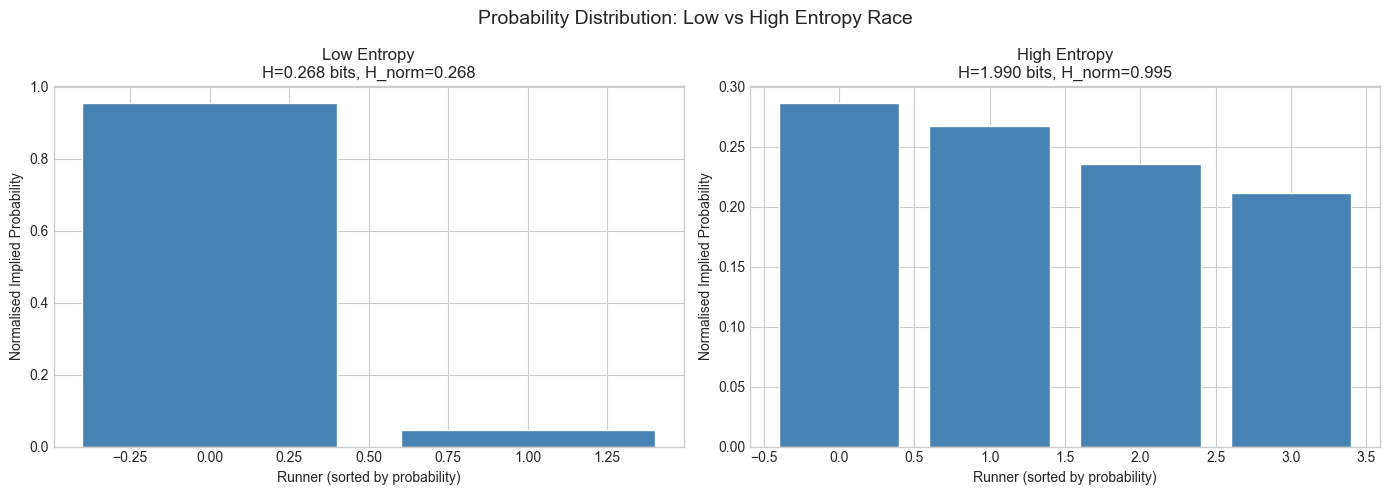

In [8]:
# Side-by-side: low entropy race vs high entropy race
entries = pd.read_csv(DATA_DIR / 'entries_market.csv', parse_dates=['meet_date'])

# Find a low-entropy and high-entropy race
race_features = pd.read_csv(REPO_ROOT / 'data' / 'processed' / 'race_features.csv',
                            parse_dates=['meet_date'])
low_race = race_features.nsmallest(1, 'entropy_H_norm').iloc[0]
high_race = race_features.nlargest(1, 'entropy_H_norm').iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, race, label in [(axes[0], low_race, 'Low Entropy'),
                         (axes[1], high_race, 'High Entropy')]:
    rdf = entries[(entries['meet_date'] == race['meet_date']) &
                  (entries['venue'] == race['venue']) &
                  (entries['race_no'] == race['race_no'])]
    rdf = rdf.sort_values('implied_prob_norm', ascending=False)
    ax.bar(range(len(rdf)), rdf['implied_prob_norm'], color='steelblue', edgecolor='white')
    ax.set_xlabel('Runner (sorted by probability)')
    ax.set_ylabel('Normalised Implied Probability')
    ax.set_title(f'{label}\nH={race["entropy_H"]:.3f} bits, H_norm={race["entropy_H_norm"]:.3f}')

fig.suptitle('Probability Distribution: Low vs High Entropy Race', fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / 'unit1_low_vs_high_entropy.png', **SAVEKW)
plt.show()

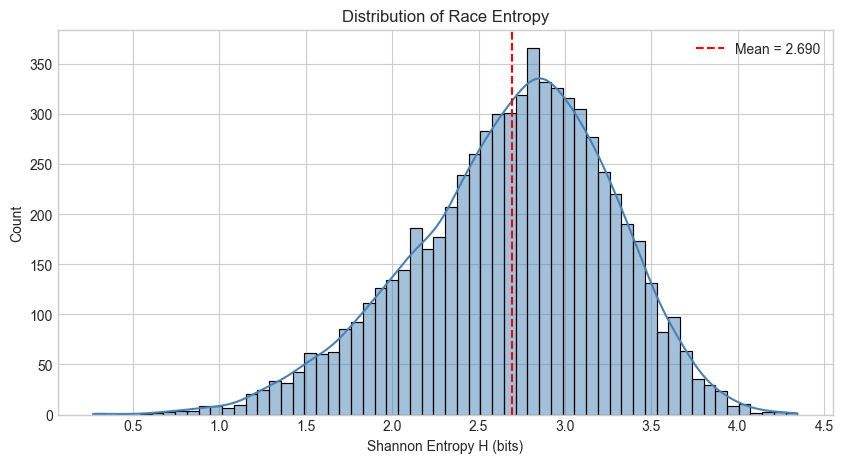

In [9]:
# Distribution of entropy values
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['entropy_H'].dropna(), bins=60, kde=True, ax=ax, color='steelblue')
ax.axvline(df['entropy_H'].mean(), color='red', ls='--', label=f'Mean = {df["entropy_H"].mean():.3f}')
ax.set_xlabel('Shannon Entropy H (bits)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Race Entropy')
ax.legend()
fig.savefig(FIG_DIR / 'unit1_entropy_histogram.png', **SAVEKW)
plt.show()

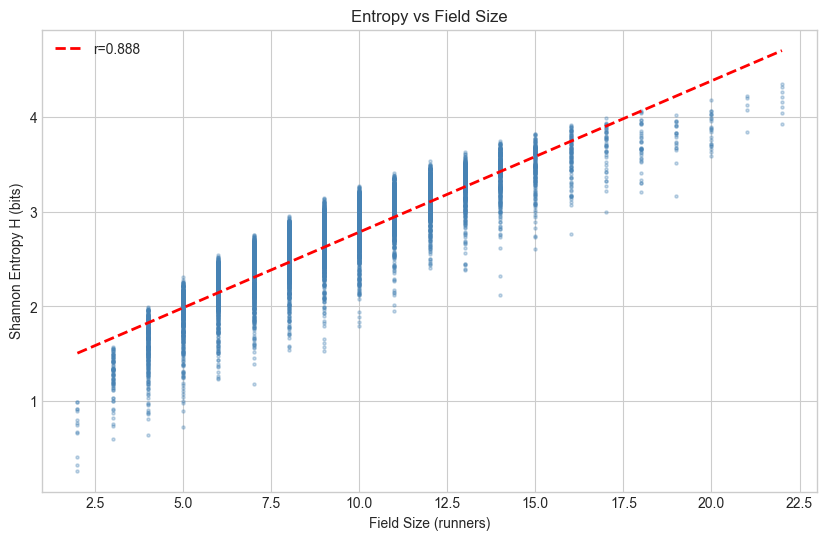

In [10]:
# Entropy vs field size
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['field_size'], df['entropy_H'], s=5, alpha=0.3, color='steelblue')
slope, intercept, r, p, se = stats.linregress(df['field_size'].dropna(), df['entropy_H'].dropna())
x_line = np.linspace(df['field_size'].min(), df['field_size'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', lw=2, label=f'r={r:.3f}')
ax.set_xlabel('Field Size (runners)')
ax.set_ylabel('Shannon Entropy H (bits)')
ax.set_title('Entropy vs Field Size')
ax.legend()
fig.savefig(FIG_DIR / 'unit1_entropy_vs_field_size.png', **SAVEKW)
plt.show()

## Section 2 — Autocorrelation (Experiment #2)

We compute the autocorrelation of the entropy signal to determine whether
there is temporal dependence — i.e., does the market have 'memory'?

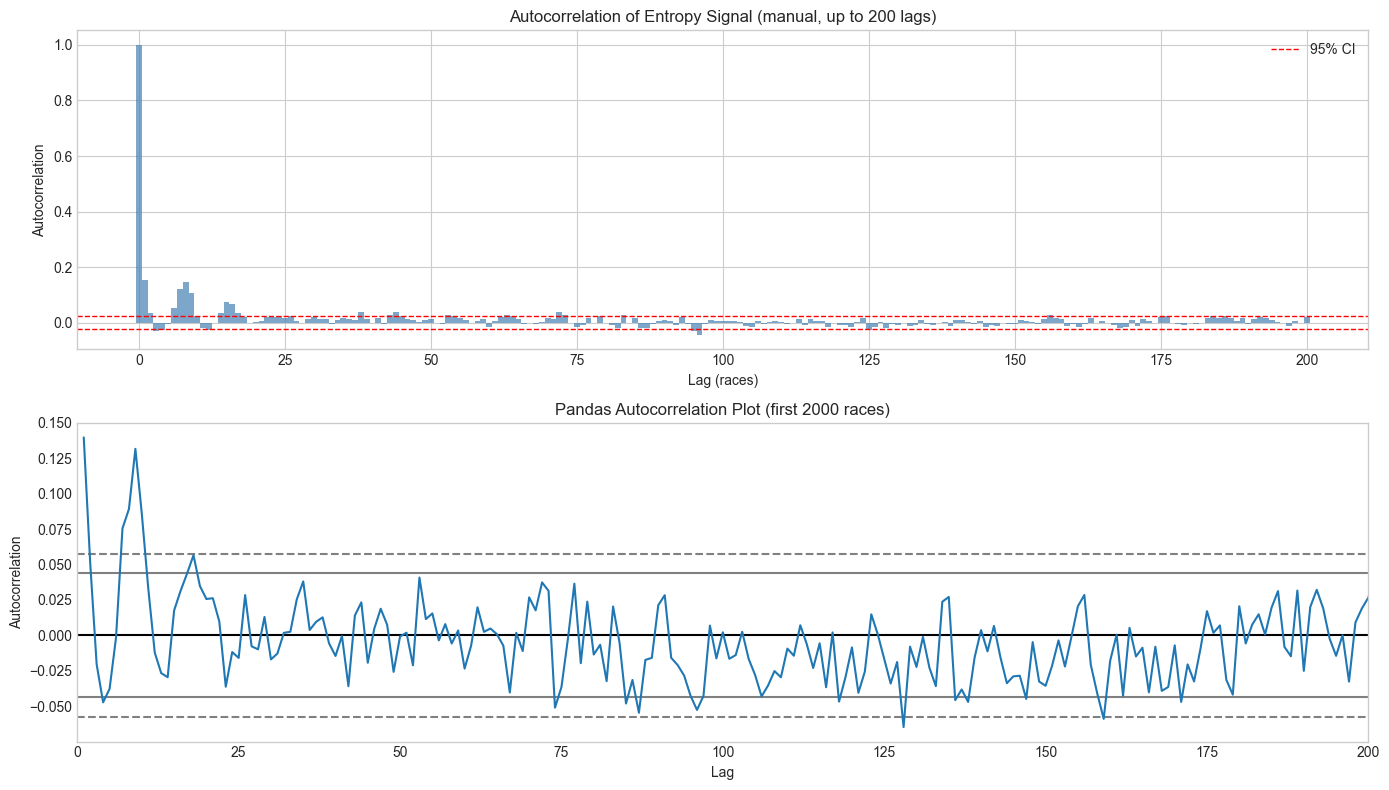

In [11]:
# Manual autocorrelation using numpy.correlate
H = df['entropy_H'].dropna().values
H_centered = H - H.mean()
n = len(H_centered)
max_lag = 200

# Full correlation
full_corr = np.correlate(H_centered, H_centered, mode='full')
# Normalise by variance and n
acf_manual = full_corr[n - 1: n - 1 + max_lag + 1] / (H_centered.var() * n)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(range(max_lag + 1), acf_manual, width=1, color='steelblue', alpha=0.7)
axes[0].axhline(1.96 / np.sqrt(n), color='red', ls='--', lw=1, label='95% CI')
axes[0].axhline(-1.96 / np.sqrt(n), color='red', ls='--', lw=1)
axes[0].set_xlabel('Lag (races)')
axes[0].set_ylabel('Autocorrelation')
axes[0].set_title('Autocorrelation of Entropy Signal (manual, up to 200 lags)')
axes[0].legend()

# Pandas autocorrelation plot for comparison
pd.plotting.autocorrelation_plot(pd.Series(H[:2000]), ax=axes[1])
axes[1].set_title('Pandas Autocorrelation Plot (first 2000 races)')
axes[1].set_xlim(0, max_lag)

fig.tight_layout()
fig.savefig(FIG_DIR / 'unit1_autocorrelation.png', **SAVEKW)
plt.show()

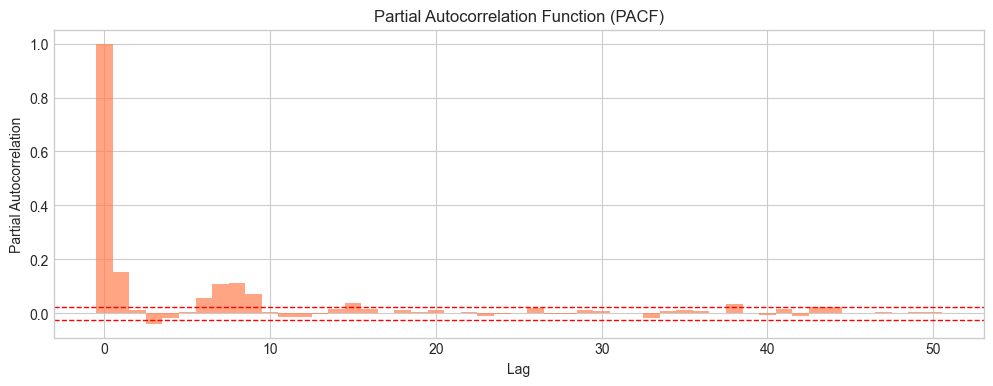

Significant autocorrelation at lags: [ 1  2  3  4  6  7  8  9 10 12 14 15 16 17 26 38 43 44 53 54] ...
ACF at lag 1: 0.1549
Interpretation: positive ACF at short lags → short-term market memory.


In [12]:
# Partial autocorrelation
pacf_vals = pacf(H, nlags=50, method='ywm')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(pacf_vals)), pacf_vals, width=1, color='coral', alpha=0.7)
ax.axhline(1.96 / np.sqrt(n), color='red', ls='--', lw=1)
ax.axhline(-1.96 / np.sqrt(n), color='red', ls='--', lw=1)
ax.set_xlabel('Lag')
ax.set_ylabel('Partial Autocorrelation')
ax.set_title('Partial Autocorrelation Function (PACF)')
fig.savefig(FIG_DIR / 'unit1_pacf.png', **SAVEKW)
plt.show()

# Interpretation
sig_lags = np.where(np.abs(acf_manual[1:]) > 1.96 / np.sqrt(n))[0] + 1
print(f'Significant autocorrelation at lags: {sig_lags[:20]} ...')
print(f'ACF at lag 1: {acf_manual[1]:.4f}')
print('Interpretation: positive ACF at short lags → short-term market memory.')

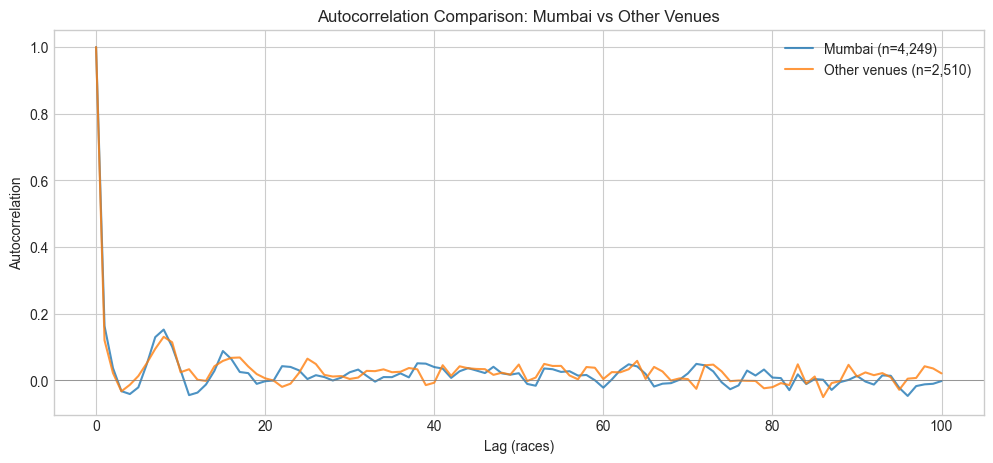

In [13]:
# Autocorrelation: Mumbai vs rest
mumbai = df[df['venue'] == 'Mumbai']['entropy_H'].dropna().values
other = df[df['venue'] != 'Mumbai']['entropy_H'].dropna().values

def compute_acf(x, max_lag=100):
    """Compute normalised autocorrelation."""
    xc = x - x.mean()
    full = np.correlate(xc, xc, mode='full')
    n = len(xc)
    return full[n-1:n-1+max_lag+1] / (xc.var() * n)

fig, ax = plt.subplots(figsize=(12, 5))
lags = range(101)
ax.plot(lags, compute_acf(mumbai, 100), label=f'Mumbai (n={len(mumbai):,})', alpha=0.8)
ax.plot(lags, compute_acf(other, 100), label=f'Other venues (n={len(other):,})', alpha=0.8)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Lag (races)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation Comparison: Mumbai vs Other Venues')
ax.legend()
fig.savefig(FIG_DIR / 'unit1_acf_mumbai_vs_rest.png', **SAVEKW)
plt.show()

## Section 3 — Convolution / Moving Average (Experiment #3)

We apply convolution-based smoothing to the entropy signal using uniform kernels
of varying widths to reveal different temporal scales of structure.

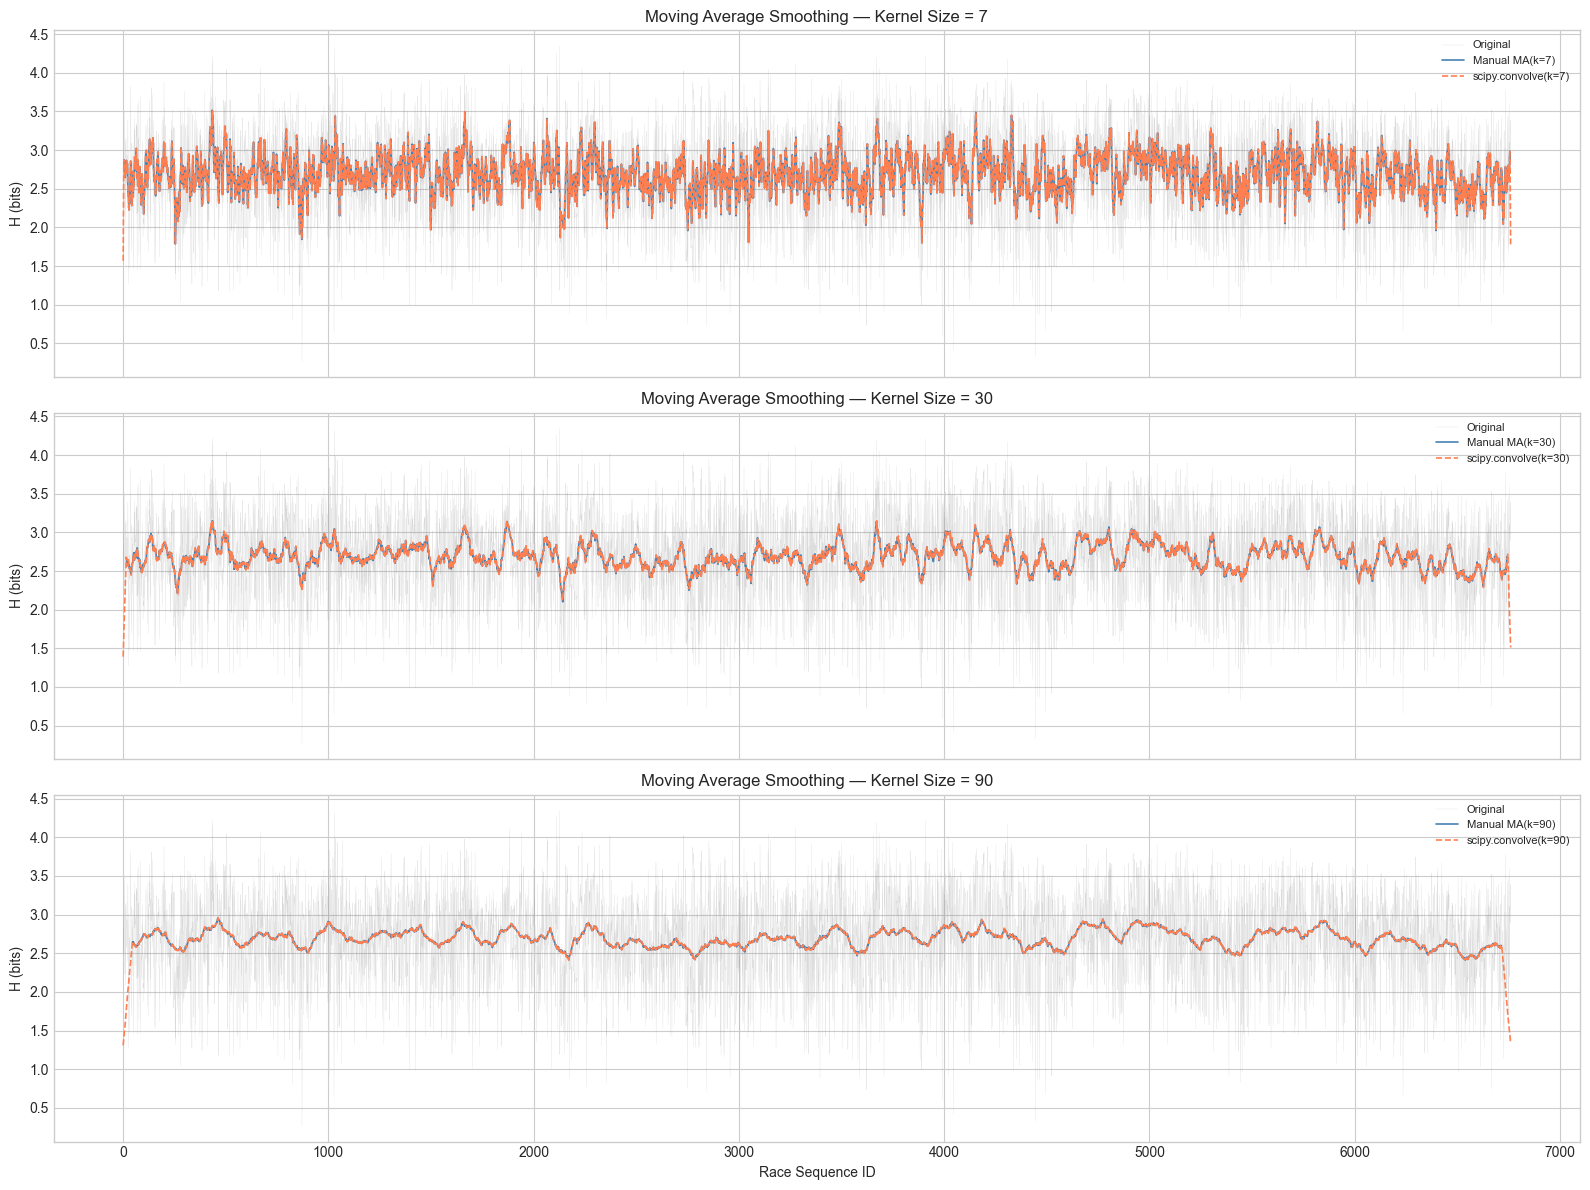

In [14]:
# Manual convolution with uniform kernel vs scipy.signal.convolve
H = df['entropy_H'].values.copy()
seq_ids = df['race_seq_id'].values

def manual_moving_avg(x, k):
    """Compute moving average via manual convolution loop."""
    n = len(x)
    out = np.full(n, np.nan)
    half = k // 2
    for i in range(half, n - half):
        out[i] = np.mean(x[i - half: i + half + 1])
    return out

kernel_sizes = [7, 30, 90]

fig, axes = plt.subplots(len(kernel_sizes), 1, figsize=(16, 4 * len(kernel_sizes)), sharex=True)

for ax, k in zip(axes, kernel_sizes):
    # Manual
    manual = manual_moving_avg(H, k)
    # scipy
    kernel = np.ones(k) / k
    scipy_conv = sp_signal.convolve(H, kernel, mode='same')

    ax.plot(seq_ids, H, lw=0.2, alpha=0.3, color='gray', label='Original')
    ax.plot(seq_ids, manual, lw=1.2, color='steelblue', label=f'Manual MA(k={k})')
    ax.plot(seq_ids, scipy_conv, lw=1.2, color='coral', ls='--', label=f'scipy.convolve(k={k})')
    ax.set_ylabel('H (bits)')
    ax.set_title(f'Moving Average Smoothing — Kernel Size = {k}')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Race Sequence ID')
fig.tight_layout()
fig.savefig(FIG_DIR / 'unit1_convolution_smoothing.png', **SAVEKW)
plt.show()

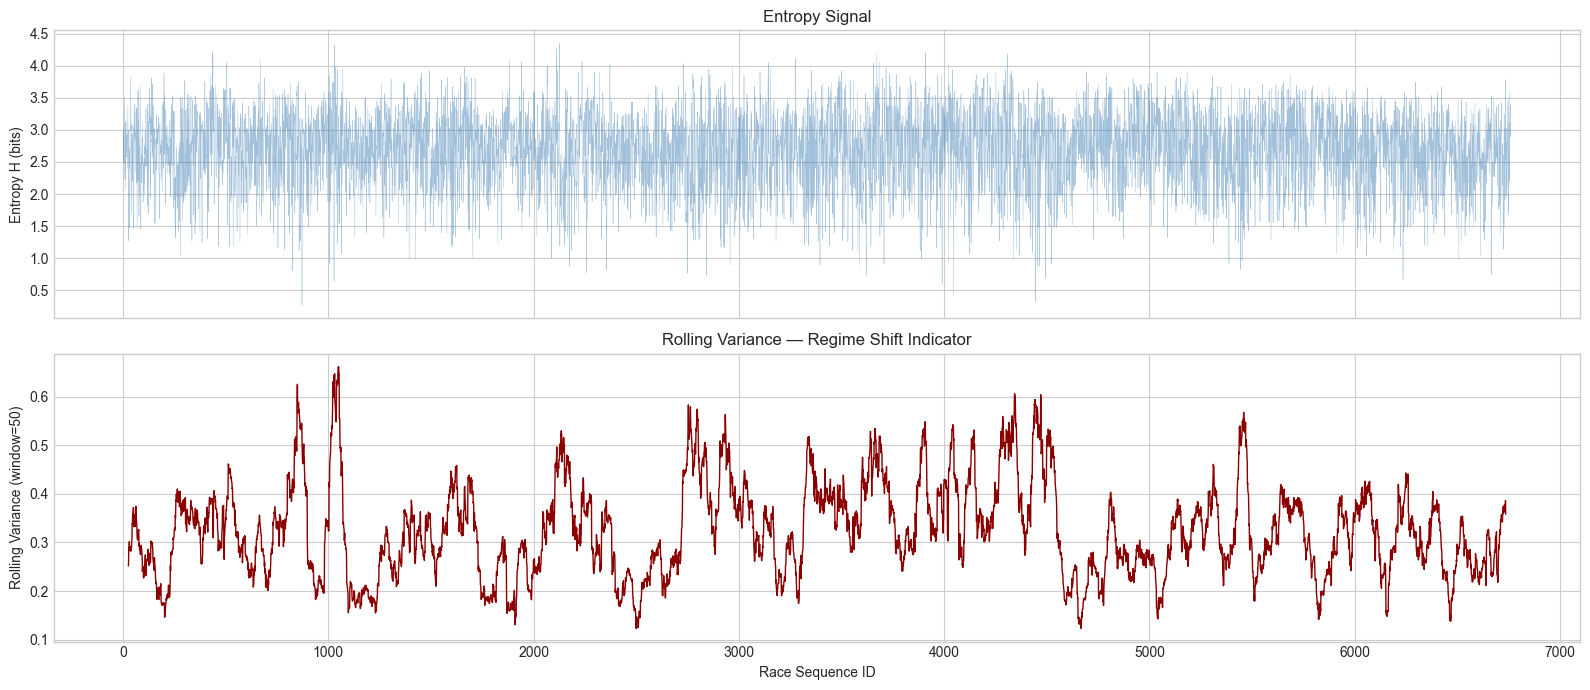

In [15]:
# Rolling variance to detect regime shifts
rolling_var = pd.Series(H).rolling(window=50, center=True).var()

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
axes[0].plot(seq_ids, H, lw=0.3, alpha=0.5, color='steelblue')
axes[0].set_ylabel('Entropy H (bits)')
axes[0].set_title('Entropy Signal')

axes[1].plot(seq_ids, rolling_var, lw=1, color='darkred')
axes[1].set_ylabel('Rolling Variance (window=50)')
axes[1].set_xlabel('Race Sequence ID')
axes[1].set_title('Rolling Variance — Regime Shift Indicator')

fig.tight_layout()
fig.savefig(FIG_DIR / 'unit1_rolling_variance.png', **SAVEKW)
plt.show()

## Summary

- The entropy signal shows moderate short-term autocorrelation, suggesting some degree of market memory.
- Moving average convolution at different scales reveals weekly (~7 race), monthly (~30), and seasonal (~90) patterns.
- Rolling variance highlights periods of volatile vs stable market uncertainty.